# Clustering Results - Volatility Regime Grouping (K-Means)

INFS3208 Individual Project - Distributed Market Analytics

Loads the K-Means model already trained and saved by `src/models/clustering.py`.
Each window's features are z-scored **per stock** (mean/std fit on train only,
via `cluster_stock_stats.parquet`) before clustering, so a cluster means
"unusually calm/volatile *for this stock*", comparable across all 112 stocks
rather than just re-discovering which stock is which. This task is
unsupervised - `target` (next-window realized volatility) is never used to
fit the model, only afterwards to help interpret what each cluster means.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

sys.path.append(str(Path("../src/pipeline").resolve()))
sys.path.append(str(Path("../src/models").resolve()))

from spark_session import get_spark
from regression import FEATURE_COLS, DATA_PROCESSED, load_split
from clustering import MODELS_DIR, apply_per_stock_zscore
from pyspark.ml import PipelineModel
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql import functions as F

spark = get_spark()
model = PipelineModel.load(str(MODELS_DIR / "clustering_best"))
kmeans_model = model.stages[-1]
k = kmeans_model.getK()
stats = spark.read.parquet(str(DATA_PROCESSED / "cluster_stock_stats.parquet")).cache()
print("Loaded model: KMeans | k =", k)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/22 06:41:39 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loaded model: KMeans | k = 2


## 1. Silhouette score across all three splits

Silhouette measures how well-separated the clusters are (closer to 1 is
better; near 0 means clusters overlap). Reporting it on all three splits
checks the clustering isn't overfit to the training data.

In [2]:
def load_z(name):
    df = load_split(spark, name)
    return apply_per_stock_zscore(df, stats)

evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="cluster")

rows = []
preds = {}
for split_name in ["train", "val", "test"]:
    df_z = load_z(split_name)
    pred = model.transform(df_z)
    sil = evaluator.evaluate(pred)
    rows.append({"split": split_name, "silhouette": sil})
    preds[split_name] = pred

metrics_table = pd.DataFrame(rows).set_index("split")
metrics_table

26/09/22 06:41:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/22 06:41:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



[Stage 13:====>                                                    (4 + 2) / 49]




[Stage 16:====================>                                   (18 + 2) / 49]




[Stage 16:=============================================>          (40 + 2) / 49]




[Stage 22:==================================================>     (44 + 2) / 49]




[Stage 25:====================================================>   (46 + 2) / 49]




[Stage 34:==================================================>     (44 + 2) / 49]



,silhouette
split,
train,0.619474
val,0.629028
test,0.617762


## 2. Cluster sizes and interpretation - test set

Same interpretation table as the training run, computed fresh here: cluster
counts and the average of a few original-unit (not z-scored) features per
cluster.

In [3]:
describe_cols = ["realized_vol_book", "avg_spread_bps", "trade_volume", "target"]
test_pred = preds["test"]

cluster_summary = (
    test_pred.groupBy("cluster")
    .agg(
        F.count("*").alias("n_windows"),
        *[F.avg(c).alias(f"avg_{c}") for c in describe_cols],
    )
    .orderBy("cluster")
    .toPandas()
)
cluster_summary["pct_of_windows"] = cluster_summary["n_windows"] / cluster_summary["n_windows"].sum()
cluster_summary

,cluster,n_windows,avg_realized_vol_book,avg_avg_spread_bps,avg_trade_volume,avg_target,pct_of_windows
0,0,51379,0.002261,5.471866,22961.267502,0.003164,0.851139
1,1,8986,0.006034,11.404738,74040.619519,0.007046,0.148861


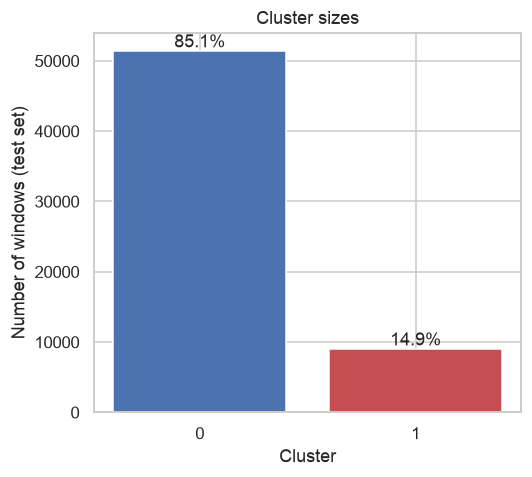

In [4]:
fig, ax = plt.subplots(figsize=(5, 4.5))
colors = ["#4C72B0", "#C44E52", "#55A868", "#DD8452", "#8172B2"][:k]
ax.bar(cluster_summary["cluster"].astype(str), cluster_summary["n_windows"], color=colors)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of windows (test set)")
ax.set_title("Cluster sizes")
for i, row in cluster_summary.iterrows():
    ax.text(i, row["n_windows"], f"{row['pct_of_windows']:.1%}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Feature distributions by cluster

Box plots of the key original-unit features, split by cluster, make the
calm-vs-stressed story visible directly rather than just as an average.

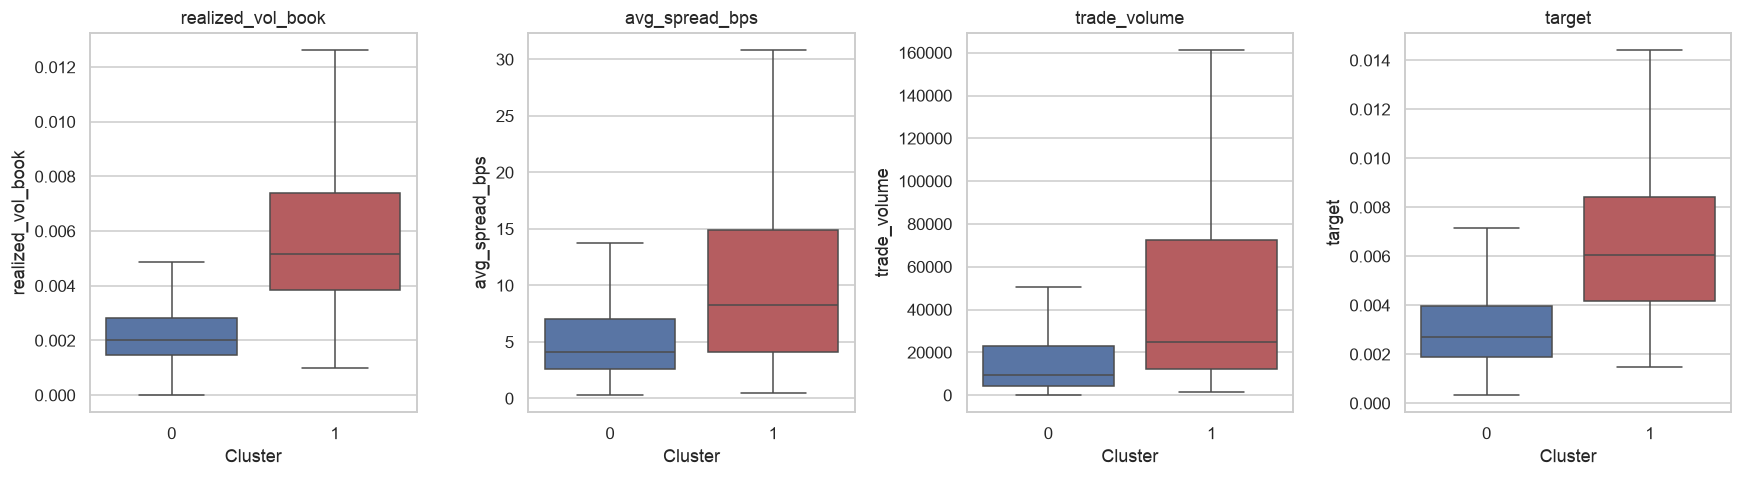

In [5]:
sample_pd = test_pred.select("cluster", *describe_cols).sample(fraction=0.05, seed=42).toPandas()

fig, axes = plt.subplots(1, len(describe_cols), figsize=(4 * len(describe_cols), 4.5))
for ax, col in zip(axes, describe_cols):
    sns.boxplot(data=sample_pd, x="cluster", y=col, hue="cluster", palette=colors, legend=False, ax=ax, showfliers=False)
    ax.set_title(col)
    ax.set_xlabel("Cluster")
plt.tight_layout()
plt.show()

## 4. 2D projection of the clustering feature space (PCA)

The clustering itself runs in 12-dimensional (z-scored) feature space; PCA
to 2 components is only for visualization, so cluster boundaries may look
softer here than they actually are in the full space.

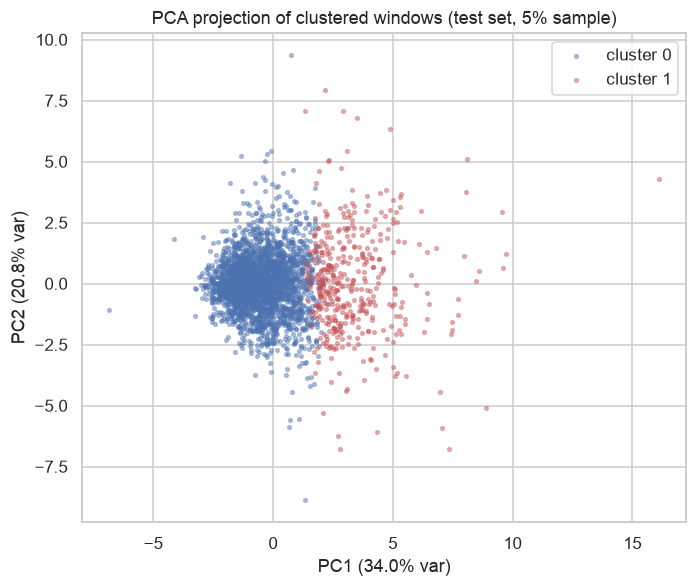

In [6]:
feat_sample = test_pred.select("features", "cluster").sample(fraction=0.05, seed=42).toPandas()
X = np.vstack(feat_sample["features"].apply(lambda v: v.toArray()).values)

pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(X)
feat_sample["pc1"], feat_sample["pc2"] = proj[:, 0], proj[:, 1]

plt.figure(figsize=(6.5, 5.5))
for c in sorted(feat_sample["cluster"].unique()):
    sub = feat_sample[feat_sample["cluster"] == c]
    plt.scatter(sub["pc1"], sub["pc2"], s=6, alpha=0.4, color=colors[c], label=f"cluster {c}")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.title("PCA projection of clustered windows (test set, 5% sample)")
plt.legend()
plt.tight_layout()
plt.show()

## Takeaways

- **k=2 was selected on validation silhouette (0.629), well ahead of k=3/4/5
  (0.35/0.32/0.25)**, and the test silhouette (0.618) confirms it
  generalizes - the dominant structure in this feature space is a clean
  two-way split, not several fine-grained regimes.
- **Cluster 0 ("calm", ~85% of windows)**: low realized volatility, tight
  spreads (~5.5 bps), modest trade volume.
  **Cluster 1 ("stressed", ~15% of windows)**: ~2.7x higher realized
  volatility, ~2x wider spreads, ~3.2x more trade volume, and higher average
  next-window target - a textbook market-microstructure result where
  liquidity dries up (spreads widen) exactly when volatility and trading
  activity spike.
- This is unsupervised: `target` was never used to fit K-Means, only shown
  afterward to help interpret what the two clusters mean. That the
  "stressed" cluster also has the higher average next-window volatility
  target is an independent sanity check that the clusters correspond to a
  real, persistent regime rather than an artifact.
- Per-stock z-scoring (fit on train only) was the key design choice here -
  without it, clusters risk mostly encoding "which stock is this" given the
  large baseline volatility differences across the 112 stocks seen in the
  EDA.

In [7]:
spark.stop()